In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches


In [3]:
def input_answers():
    inp = []
    print('Gib die Antwortmöglichkeiten an: \n (wenn alle Antwormöglichkeiten eingegeben wurden drücke Enter)')
    while True:
        answer = input()
        if answer == '':
            if len(inp) < 2:
                print('Zu wenig Antwortmöglichkeiten ausgewählt!')
                continue
            break
        inp.append(answer)
    return inp

In [ ]:
def input_min_max(n_answers):
    while True:
        try:
            print('Wenn gewünscht gebt nun die mögliche Skala ein:')
            if n_answers == 2:
                mini = int(input('Minimaler Wert (default -5): ') or -5)
            else:
                mini = int(input('Minimaler Wert (default 0): ') or 0)
            maxi = int(input('Maximaler Wert (default 5): ') or 5)
            if mini >= maxi:
                print('Minimaler Wert muss kleiner als maximaler Wert sein. Bitte erneut eingeben.')
                continue
            return mini, maxi
        except ValueError:
            print('Ungültige Eingabe. Bitte geben Sie ganze Zahlen für minimal und maximal ein.')

In [ ]:
def input_vote(answers, n_answers, question, mini, maxi):
    
    if n_answers == 2:
        df = pd.DataFrame(columns=['Name'] + ['Answer'])
        while True:
            # print('Gib deinen Namen ein:')
            name = input('Gib deinen Namen ein:')
            if name == '':
                break
                # print('Name darf nicht leer sein. Bitte erneut eingeben.')
                # continue
            print(question)
            print(f'Gib deine Zustimmung zu den Antwortmöglichkeiten ein (negativ für {answers[0]}; positiv für {answers[1]})')
            while True:
                try:
                    answer = int(input())
                    if answer < mini or answer > maxi:
                        print(f'Bitte gib eine ganze Zahl zwischen {mini} und {maxi} ein.')
                        continue
                except ValueError:
                    print('Ungültige Eingabe. Bitte gib eine ganze Zahl ein.')
                    continue
                break
            new_df = pd.DataFrame({'Name': name, 'Answer': answer}, index=[0])
            df = pd.concat([df, new_df], ignore_index=True)
    if n_answers > 2:
        df = pd.DataFrame(columns=['Name'] + [ans for ans in answers])
        print(f'Gebt nun eure Zustimmung zu den Abstimmmöglichkeiten in ganzen Zahlen zwischen {mini} und {maxi} an:')
        while True:
            # print('Gib deinen Namen ein:')
            name = input('Gib deinen Namen ein:')
            if name == '':
                break
                # print('Name darf nicht leer sein. Bitte erneut eingeben.')
                # continue
            inp_answers = []
            print(question)
            for i in range(n_answers):
                print(f'Wie sehr bist du für bzw. gegen Option: {answers[i]}')
                while True:
                    try:
                        answer = int(input())
                        if answer < mini or answer > maxi:
                            print(f'Bitte gib eine ganze Zahl zwischen {mini} und {maxi} ein.')
                            continue
                    except ValueError:
                        print('Ungültige Eingabe. Bitte gib eine ganze Zahl ein.')
                        continue
                    break    
                inp_answers.append(answer)
            new_df = pd.DataFrame({'Name': name, **{answers[i]: inp_answers[i] for i in range(n_answers)}}, index=[0])
            df = pd.concat([df, new_df], ignore_index=True)
    return df

In [ ]:
answers = ['Buch', 'Film', 'Raus']
answers = ['Buch', 'Film']

question = 'Was machen wir heute?'
mini, maxi = -5, 5
n_answers = len(answers)


df = input_vote(answers, n_answers, question, mini, maxi)

Gebt nun eure Zustimmung zu den Abstimmmöglichkeiten in ganzen Zahlen zwischen -5 und 5 an:
Gib deinen Namen ein:
Was machen wir heute?
Wie sehr bist du für bzw. gegen Option: Buch
Wie sehr bist du für bzw. gegen Option: Film
Ungültige Eingabe. Bitte gib eine ganze Zahl ein.
Wie sehr bist du für bzw. gegen Option: Raus
Gib deinen Namen ein:


In [130]:
df

,Name,Buch,Film,Raus
0,Tom,1,2,3
1,Max,0,3,0
2,Timo,2,4,1


In [7]:
def input_visualisation():
    print('Welche Darstellungsoptionen der Ergebnisse sollen angezeigt werden?')
    print('1 = Alle Grafiken, 2 = Text')
    possible_options = [1, 2]
    while True:
        try:
            figs = int(input())
            if figs not in possible_options:
                print(f'Ungültige Eingabe. Bitte gib eine der Optionen von {possible_options[0]} bis {possible_options[-1]} ein.')
                continue
            break
        except ValueError:
            print('Ungültige Eingabe. Bitte gib eine ganze Zahl ein.')
            continue
    return figs

In [ ]:
def input_part():
    question = input('Gib die Fragestellung der Umfrage ein:')
    answers = input_answers()
    n_answers = len(answers)
    mini, maxi = input_min_max(n_answers)
    df = input_vote(answers, n_answers, question, mini, maxi)
    figs = input_visualisation()
    return df, figs, n_answers, answers, question


In [103]:
df

,Name,Answer
0,Tom,-4
1,Tim,-3
2,Marie,5
3,Pia,2
4,Mark,0


In [ ]:
def plot_bar(df, question, answers):
    names = df['Name'].tolist()
    values = df['Answer'].to_numpy()

    colors = plt.colormaps['RdYlGn'](
        np.linspace(0.15, 0.85, len(values))
    )

    fig, ax = plt.subplots(figsize=(9.2, 1))
    ax.invert_yaxis()

    negative_sum = np.sum(values[values < 0])
    positive_sum = np.sum(values[values > 0])
    abs_max = np.max((negative_sum*-1, positive_sum))
    total = negative_sum + positive_sum

    ax.set_xlim(-abs_max, abs_max)
    ax.set_xticks(range(-abs_max, abs_max + 1))
    ax.set_yticks([])
    ax.set_title(question, fontsize=14, fontweight='bold', pad=15, loc='left')
    # Remove Box from plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)

    ax.text(0, -0.5, answers[0], transform=ax.transAxes, ha='left', va='center', fontsize=12)
    ax.text(1, -0.5, answers[1], transform=ax.transAxes, ha='right', va='center', fontsize=12)

    pos_cum = 0
    neg_cum = negative_sum

    for name, value, color in zip(names, values, colors):

        if value > 0:
            start = pos_cum
            pos_cum += value
        elif value < 0:
            start = neg_cum - value
            neg_cum -= value
        else:
            start = 0

        rects = ax.barh(" ", value, left=start, height=0.5, color=color)

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.5 else 'darkgrey'

        ax.bar_label(rects, labels=[name], label_type='center', color=text_color)

    ax.vlines(0, -0.5, 0.5, color='black', linewidth=0.8)
    ax.vlines(total, -0.5, 0.5, color='Red', linewidth=2)
    ax.text(total, -0.8, 'Meinung des Volkes', transform=ax.transData, ha='center', va='top', fontsize=10, color='Red')
    plt.show()

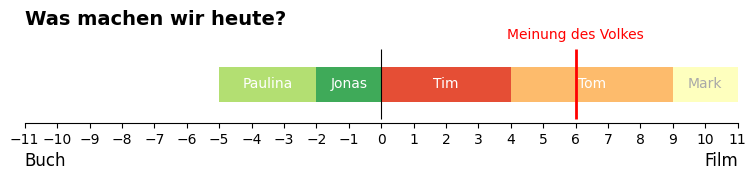

In [ ]:
plot_bar(df, question, answers)

In [131]:
df

,Name,Buch,Film,Raus
0,Tom,1,2,3
1,Max,0,3,0
2,Timo,2,4,1


In [ ]:
def plot_coord(df, question, answers):
    # make a 3d coordinate system with points for the position of each person and a mean point
    # Add the Durchschnitt row
    df_avg = pd.DataFrame({'Name': 'Durchschnitt', 
                        **{df.columns[1:][i]: df[df.columns[1:][i]].mean() 
                            for i in range(len(df.columns[1:]))}}, index=[0])
    df_fin = pd.concat([df, df_avg], ignore_index=True)

    # Format the names with rounded values
    for i in range(len(df_fin['Name'])):
        df_fin.loc[i, 'Name'] = f"{df_fin.loc[i, 'Name']} ({round(df_fin.iloc[i,1],2)}|{round(df_fin.iloc[i,2],2)}|{round(df_fin.iloc[i,3],2)})"

    # Convert Names to categorical codes
    names = df_fin['Name'].astype('category')
    codes = names.cat.codes
    unique_names = names.cat.categories

    # Create color map
    cmap = plt.get_cmap('tab10')  # use tab10 or tab20 for more participants
    n_colors = len(unique_names)
    colors = cmap(codes / (n_colors - 1 if n_colors > 1 else 1))  # normalize to [0,1]

    # Data
    xs = pd.to_numeric(df_fin[answers[0]], errors='coerce').to_numpy()
    ys = pd.to_numeric(df_fin[answers[1]], errors='coerce').to_numpy()
    zs = pd.to_numeric(df_fin[answers[2]], errors='coerce').to_numpy()

    # Wider figure with GridSpec
    fig = plt.figure(figsize=(14,8))  # wider figure
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.3], figure=fig)
    ax = fig.add_subplot(gs[0], projection='3d')

    # Scatter plot
    scatter = ax.scatter(xs, ys, zs, c=colors, s=60, depthshade=False)
    min_val = 0
    max_val = max

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_zlim(min_val, max_val)
    ax.set_box_aspect([1,1,1])  # maintain cube aspect ratio

    # Create legend handles
    handles = [mlines.Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=cmap(i / (n_colors - 1 if n_colors > 1 else 1)),
                            markersize=8)
            for i in range(n_colors)]

    # Place legend outside the axes
    ax.legend(handles, unique_names, title='Teilnehmer', loc='center left',
            bbox_to_anchor=(1.05, 0.8), fontsize=10)

    # Projection lines for all points except the average
    for i in range(len(xs)-1):  # exclude the last point (average)
        ax.plot([xs[i], xs[i]], [ys[i], 0], [zs[i], 0], color='lightgray', linestyle='-.', alpha=0.4)
        ax.plot([xs[i], 5], [ys[i], ys[i]], [zs[i], 0], color='lightgray', linestyle='-.', alpha=0.4)
        ax.plot([xs[i], 5], [ys[i], 5], [zs[i], zs[i]], color='lightgray', linestyle='-.', alpha=0.4)

    # Average point coordinates
    avg_x, avg_y, avg_z = xs[-1], ys[-1], zs[-1]

    # Projection lines for average point
    ax.plot([avg_x, avg_x], [avg_y, 0], [avg_z, 0], color='gray', linestyle='--', alpha=0.7)
    ax.plot([avg_x, 5], [avg_y, avg_y], [avg_z, 0], color='gray', linestyle='--', alpha=0.7)
    ax.plot([avg_x, 5], [avg_y, 5], [avg_z, avg_z], color='gray', linestyle='--', alpha=0.7)

    # Highlight the max axis with red line
    if avg_x >= avg_y and avg_x >= avg_z:
        ax.plot([avg_x, avg_x], [avg_y, 0], [avg_z, 0], color='red', linestyle='--', alpha=0.7)
    if avg_y >= avg_x and avg_y >= avg_z:
        ax.plot([avg_x, 5], [avg_y, avg_y], [avg_z, 0], color='red', linestyle='--', alpha=0.7)
    if avg_z >= avg_x and avg_z >= avg_y:
        ax.plot([avg_x, 5], [avg_y, 5], [avg_z, avg_z], color='red', linestyle='--', alpha=0.7)

    # Highlight average point
    ax.scatter(avg_x, avg_y, avg_z, color='black', s=100)

    # Axis ticks
    ax.set_xticks(range(min_val, max + 1))
    ax.set_yticks(range(min_val, max + 1))
    ax.set_zticks(range(min_val, max + 1))

    # Labels
    ax.set_title(question, fontsize=14, fontweight='bold', pad=15, loc='left')
    ax.set_xlabel(answers[0])
    ax.set_ylabel(answers[1])
    ax.set_zlabel(answers[2])
    ax.zaxis.label.set_rotation(90)

    plt.show()
        

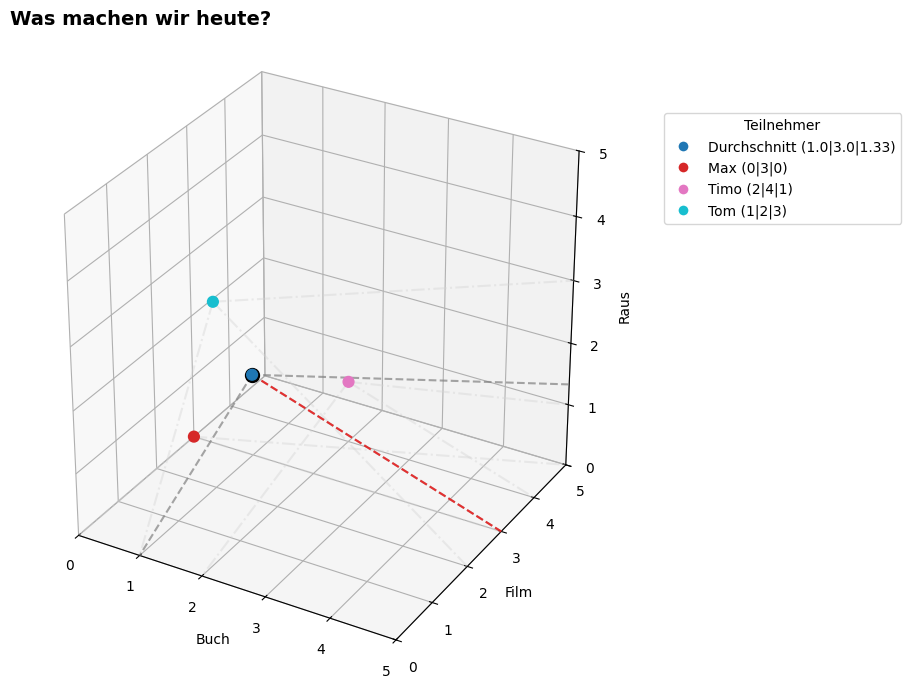

In [ ]:
plot_coord(df, question, answers)

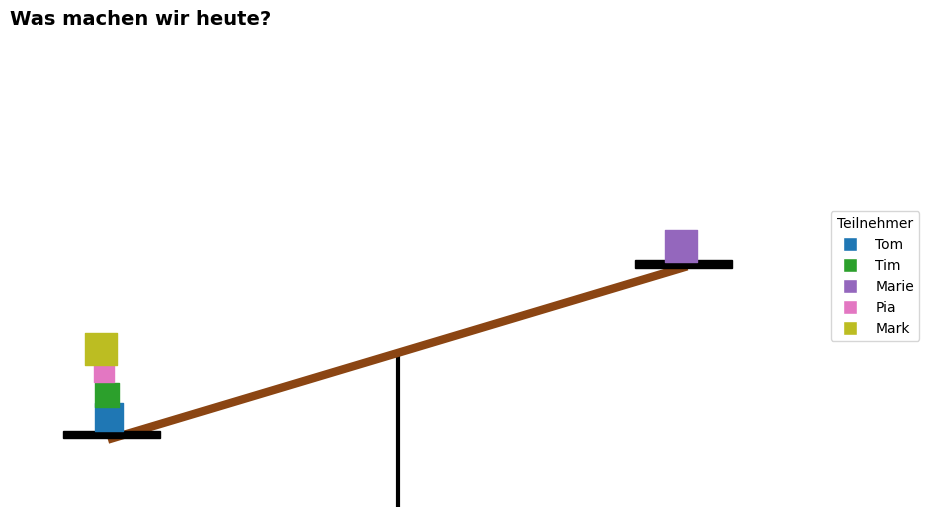

In [142]:


# Example dataframe
df = pd.DataFrame({
    'Name': ['Tom','Tim','Marie','Pia','Mark'],
    'Answer': [-4,-3,5,-2,-5]
})

def plot_waage(df, question, answers):
    # Separate negatives and positives
    df_neg = df[df['Answer'] < 0].copy()
    df_pos = df[df['Answer'] >= 0].copy()
    
    # Total weights
    left_weight = df_neg['Answer'].abs().sum()
    right_weight = df_pos['Answer'].abs().sum()
    
    # Beam settings
    width = 6
    height = 1
    max_tilt = np.pi / 8  # max ~22.5 degrees
    total = left_weight + right_weight
    # Invert tilt so heavier side goes down
    angle = max_tilt * (left_weight - right_weight)/total if total != 0 else 0
    
    # Beam endpoints
    x0, y0 = -width/2, height
    x1, y1 = width/2, height
    cx, cy = 0, height
    
    # Rotate function
    def rotate(x, y):
        xr = cx + (x-cx)*np.cos(angle) - (y-cy)*np.sin(angle)
        yr = cy + (x-cx)*np.sin(angle) + (y-cy)*np.cos(angle)
        return xr, yr
    
    x0r, y0r = rotate(x0, y0)
    x1r, y1r = rotate(x1, y1)
    
    fig, ax = plt.subplots(figsize=(10,6))
    
    # Draw beam
    ax.plot([x0r, x1r], [y0r, y1r], color='saddlebrown', lw=6, zorder=2)
    # Support
    ax.plot([0,0], [0,height], color='black', lw=3, zorder=1)
    
    # Draw pans
    pan_size = 0.5
    ax.add_patch(patches.Rectangle((x0r-pan_size, y0r), 2*pan_size, 0.1*pan_size, color='black', zorder=3))
    ax.add_patch(patches.Rectangle((x1r-pan_size, y1r), 2*pan_size, 0.1*pan_size, color='black', zorder=3))
    
    # Colors for each participant
    names = df['Name'].tolist()
    cmap = plt.get_cmap('tab10')
    colors = {name:cmap(i/len(names)) for i,name in enumerate(names)}
    
    max_abs = df['Answer'].abs().max()
    
    # Function to plot a square above a pan, rotated with the beam
    def plot_square(x_beam, y_beam, value, name, idx):
        # offset vertically above pan
        offset = 0.14 + idx*0.15
        x0s, y0s = rotate(x_beam, y_beam + offset)
        size = 500 * abs(value) / max_abs
        ax.scatter(x0s, y0s, s=size, color=colors[name], marker='s', zorder=3)
    
    # Plot negative squares on left
    for i, row in enumerate(df_neg.itertuples()):
        plot_square(x0, y0, row.Answer, row.Name, i)
    
    # Plot positive squares on right
    for i, row in enumerate(df_pos.itertuples()):
        plot_square(x1, y1, row.Answer, row.Name, i)
    
    # Legend
    handles = [mlines.Line2D([0],[0], marker='s', color='w', markerfacecolor=color, markersize=10) 
               for color in colors.values()]
    ax.legend(handles, names, title='Teilnehmer', bbox_to_anchor=(1.05,0.5), loc='center left')
    
    # Axis
    ax.set_xlim(-width/2-1, width/2+1)
    ax.set_ylim(0, height+2)
    ax.axis('off')
    ax.set_title(question, fontsize=14, fontweight='bold', pad=15, loc='left')

    plt.show()

# Test
plot_waage(df, question, answers)

In [ ]:
# Example dataframe
df = pd.DataFrame({
    'Name': ['Tom','Tim','Marie','Pia','Mark'],
    'Opt 1': [4,3,0,2,5],
    'Opt 2': [2,1,3,4,1],
    'Opt 3': [1,1,4,3,2],
    'Opt 4': [1, 4,5,3,2],
})
df

,Name,Opt 1,Opt 2,Opt 3,Opt 4
0,Tom,4,2,1,1
1,Tim,3,1,1,4
2,Marie,0,3,4,5
3,Pia,2,4,3,3
4,Mark,5,1,2,2


In [143]:
def plot_many_bars(df, question, answers):

    category_names = df.Name.tolist()

    results = {}
    for i in range(df.shape[1]-1):
        results[df.columns[i+1]] = df.iloc[:, i+1].to_list()
    
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)

    category_colors = plt.colormaps['tab10'](np.linspace(0.15, 0.85, data.shape[1]))
    
    fig, ax = plt.subplots(figsize=(9.2, 5))
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    ax.set_title(question, fontsize=14, fontweight='bold', pad=15, loc='left')
    # Remove Box from plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        # print(i)
        # print(colname, color)
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.5,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
        ax.bar_label(rects, labels=np.repeat(colname, len(rects)), label_type='center', color=text_color)
        # break
    # ax.legend(ncols=len(category_names), bbox_to_anchor=(0, 1),
    #           loc='lower left', fontsize='small')
    
    # Calculate total for each category
    totals = df.iloc[:, 1:df.shape[1]].sum(axis=0)
    totals
    winner = totals.idxmax()
    winner_idx_num = df.columns.get_loc(winner) - 1  # adjust for Name column

    ax.text(totals[winner]/2, winner_idx_num-0.4, f'Gewinner: {winner}', va='center', ha='left', fontsize=12, color='Red')
    # print(f'Gewinner: {winner} mit einem Gesamtwert von {totals[winner]}')
    # Draw a red box around the winner
    ax.add_patch(patches.Rectangle((0, winner_idx_num-0.3), totals[winner], 0.6, fill=False, edgecolor='red', linewidth=2))
    
    plt.show()
    # return fig, ax


In [ ]:
# def plot_horse_race(df, n_answers):

In [137]:
df

,Name,Answer
0,Tom,-4
1,Tim,-3
2,Marie,5
3,Pia,-2
4,Mark,-5


In [171]:
def text_answer(df, n_answers, answers):
    if n_answers == 2:
        result = df.iloc[:,1:].sum(axis=0).values[0]
        if result < 0:
            print(f'Option {answers[0]} hat gewonnen!')
        elif result == 0:
            print('Unentschieden! \n')
            print('Wollt  ihr die Abstimmung nocheinmal mit einer feineren Auflösung der Zustimmungswerte wiederholen?')
            x = int(input())
            if x == 1:
                print('ToDo')
                # praeferenz()
            else:
                print('Die Abstimmung ist beendet')
        else:
            print(f'Option {answers[1]} hat gewonnen!')
    else:
        totals = df.iloc[:, 1:df.shape[1]].sum(axis=0)
        winner = totals.idxmax()
        print(f'Option {winner} hat gewonnen!')

In [164]:
df.iloc[:,1:].sum(axis=0).values[0]

np.int64(-9)

In [174]:
# Example dataframe
df = pd.DataFrame({
    'Name': ['Tom','Tim','Marie','Pia','Mark'],
    'Answer': [4,3,0,-2,-5]
})
answers = ['Buch', 'Film']

df = pd.DataFrame({
    'Name': ['Tom','Tim','Marie','Pia','Mark'],
    'Opt 1': [4,3,0,2,5],
    'Opt 2': [2,1,3,4,1],
    'Opt 3': [1,1,4,3,2],
    'Opt 4': [1, 4,0,3,2],
})
answers = ['Opt 1', 'Opt 2', 'Opt 3', 'Opt 4']
text_answer(df, len(answers), answers)



Option Opt 1 hat gewonnen!


In [ ]:
def praeferenz():
    df, figs, n_answers, answers, question = input_part()
    
    if figs == 1 and n_answers == 2:
        plot_bar(df, question, answers)
        plot_waage(df, question, answers)
        # text_answer(df, n_answers, answers)
    if figs == 1 and n_answers == 3:
        plot_coord(df, question, answers)
        text_answer(df, n_answers, answers)
    if figs == 1 and n_answers > 3:
        plot_many_bars(df, question, answers)
        # plot_horse_race(df, n_answers)
        text_answer(df, n_answers, answers)
    if figs == 2:
        text_answer(df, n_answers, answers)
    # return df, figs, n_answers, answers
    
    

Wenn gewünscht gebt nun die mögliche Skala ein:
Gib die Antwortmöglichkeiten an: 
 (wenn alle Antwormöglichkeiten eingegeben wurden drücke Enter)
Gib deinen Namen ein:
?
Gib deine Zustimmung zu den Antwortmöglichkeiten ein (negativ für Buch; positiv für Film)
Gib deinen Namen ein:
?
Gib deine Zustimmung zu den Antwortmöglichkeiten ein (negativ für Buch; positiv für Film)
Gib deinen Namen ein:
Welche Darstellungsoptionen der Ergebnisse sollen angezeigt werden?
1 = Alle Grafiken, 2 = Text


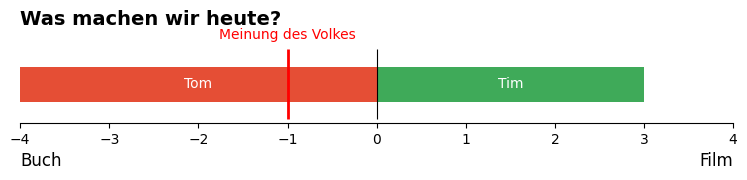

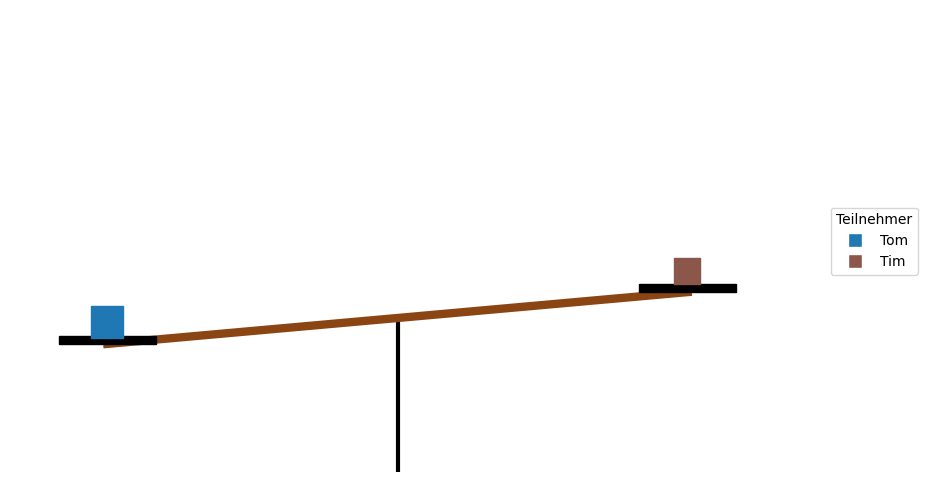

In [141]:
praeferenz()